# Algorithm-Level Imbalance Handling

Instead of resampling the data, these models handle imbalance **internally**:
Balanced Random Forest, EasyEnsemble, XGBoost (`scale_pos_weight`), and
LightGBM (`is_unbalance=True`).

## 1. Setup

In [1]:
import os
import sys
import time

import numpy as np
import pandas as pd

sys.path.insert(0, os.path.abspath('..'))

assert os.path.exists(os.path.join('..', 'data', 'Breast_Cancer.csv')), \
    "Dataset not found. Place Breast_Cancer.csv in the data/ folder."

from src.preprocessing import load_and_clean, split_features_target, get_train_test_split
from src.feature_engineering import add_features
from src.models import build_model, train_model
from src.evaluation import evaluate_model, save_results

DATA_PATH = os.path.join('..', 'data', 'Breast_Cancer.csv')
METRICS_DIR = os.path.join('..', 'results', 'metrics')
os.makedirs(METRICS_DIR, exist_ok=True)

THRESHOLD = 0.21

df = load_and_clean(DATA_PATH)
df = add_features(df)
X, y = split_features_target(df)
X_train, X_test, y_train, y_test = get_train_test_split(X, y)

scale_pos_weight = (y_train == 1).sum() / (y_train == 0).sum()
print(f'scale_pos_weight (Alive/Dead): {scale_pos_weight:.2f}')
print(f'Training class counts: {y_train.value_counts().to_dict()}')

scale_pos_weight (Alive/Dead): 5.53
Training class counts: {1: 2726, 0: 493}


## 2. Balanced Random Forest

Uses imbalanced-learn's `BalancedRandomForestClassifier` which undersamples the
majority class in each bootstrap sample. **No SMOTE pre-processing needed.**

In [2]:
print('=' * 60)
print('TRAINING: Balanced Random Forest')
print('=' * 60)

brf_metrics = None
brf_model = None

try:
    brf_model = build_model('balanced_rf')
    start = time.time()
    brf_model = train_model(brf_model, X_train, y_train)
    print(f'Trained in {time.time() - start:.1f}s')
    brf_metrics = evaluate_model(
        'Balanced RF', brf_model, X_test, y_test, threshold=THRESHOLD
    )
    print(pd.Series(brf_metrics))
except Exception as e:
    print(f'ERROR training Balanced RF: {e}')

TRAINING: Balanced Random Forest


Trained in 7.0s


model_name                        Balanced RF
threshold                                0.21
accuracy                               0.3118
recall_dead                            0.9675
precision_dead                         0.1779
f1_dead                                0.3005
f2_dead                                0.5125
roc_auc                                0.7094
pr_auc                                 0.9285
false_negatives                             4
recall_alive                           0.1935
precision_alive                        0.9706
f1_alive                               0.3227
timestamp          2026-06-16T12:26:38.112553
dtype: object


## 3. EasyEnsemble

Trains an ensemble of classifiers, each on a balanced subset of the data.
**No SMOTE pre-processing needed.**

In [3]:
print('=' * 60)
print('TRAINING: EasyEnsemble')
print('=' * 60)

ee_metrics = None
ee_model = None

try:
    ee_model = build_model('easy_ensemble')
    start = time.time()
    ee_model = train_model(ee_model, X_train, y_train)
    print(f'Trained in {time.time() - start:.1f}s')
    ee_metrics = evaluate_model(
        'EasyEnsemble', ee_model, X_test, y_test, threshold=THRESHOLD
    )
    print(pd.Series(ee_metrics))
except Exception as e:
    print(f'ERROR training EasyEnsemble: {e}')

TRAINING: EasyEnsemble


Trained in 28.6s


model_name                       EasyEnsemble
threshold                                0.21
accuracy                               0.1528
recall_dead                               1.0
precision_dead                         0.1528
f1_dead                                0.2651
f2_dead                                0.4742
roc_auc                                0.7674
pr_auc                                 0.9456
false_negatives                             0
recall_alive                              0.0
precision_alive                           0.0
f1_alive                                  0.0
timestamp          2026-06-16T12:27:09.368775
dtype: object


## 4. XGBoost with `scale_pos_weight`

TRAINING: XGBoost


Trained in 2.4s
model_name                            XGBoost
threshold                                0.21
accuracy                               0.8211
recall_dead                            0.1789
precision_dead                         0.3385
f1_dead                                 0.234
f2_dead                                0.1975
roc_auc                                0.6719
pr_auc                                 0.9195
false_negatives                           101
recall_alive                            0.937
precision_alive                        0.8635
f1_alive                               0.8987
timestamp          2026-06-16T12:27:11.863782
dtype: object


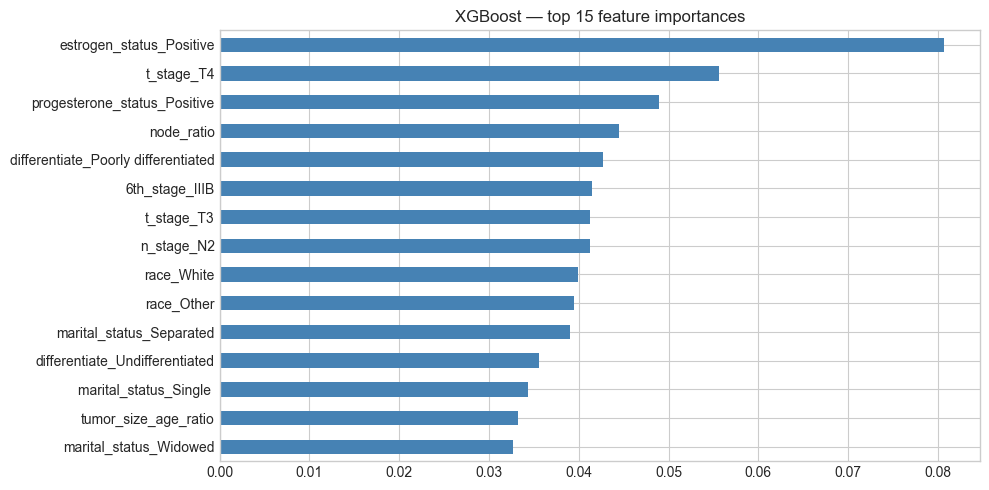

In [4]:
print('=' * 60)
print('TRAINING: XGBoost')
print('=' * 60)

xgb_metrics = None
xgb_model = None

try:
    xgb_model = build_model('xgboost', scale_pos_weight=scale_pos_weight)
    start = time.time()
    xgb_model = train_model(xgb_model, X_train, y_train)
    print(f'Trained in {time.time() - start:.1f}s')
    xgb_metrics = evaluate_model(
        'XGBoost', xgb_model, X_test, y_test, threshold=THRESHOLD
    )
    print(pd.Series(xgb_metrics))

    import matplotlib.pyplot as plt
    importance = pd.Series(
        xgb_model.feature_importances_, index=X_train.columns
    ).sort_values(ascending=False).head(15)
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(10, 5))
    importance.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title('XGBoost — top 15 feature importances')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f'ERROR training XGBoost: {e}')

## 5. LightGBM with `is_unbalance`

In [5]:
print('=' * 60)
print('TRAINING: LightGBM')
print('=' * 60)

lgbm_metrics = None
lgbm_model = None

try:
    lgbm_model = build_model('lightgbm')
    start = time.time()
    lgbm_model = train_model(lgbm_model, X_train, y_train)
    print(f'Trained in {time.time() - start:.1f}s')
    lgbm_metrics = evaluate_model(
        'LightGBM', lgbm_model, X_test, y_test, threshold=THRESHOLD
    )
    print(pd.Series(lgbm_metrics))
except Exception as e:
    print(f'ERROR training LightGBM: {e}')

TRAINING: LightGBM


Trained in 3.0s
model_name                           LightGBM
threshold                                0.21
accuracy                               0.6398
recall_dead                            0.4878
precision_dead                         0.2091
f1_dead                                0.2927
f2_dead                                0.3851
roc_auc                                0.6727
pr_auc                                 0.9177
false_negatives                            63
recall_alive                           0.6672
precision_alive                        0.8784
f1_alive                               0.7583
timestamp          2026-06-16T12:27:16.315985
dtype: object


## 6. Algorithm comparison

In [6]:
algo_results = [m for m in [brf_metrics, ee_metrics, xgb_metrics, lgbm_metrics] if m]
algo_df = pd.DataFrame(algo_results)
display_cols = ['model_name', 'recall_dead', 'precision_dead', 'f1_dead',
                'f2_dead', 'false_negatives', 'pr_auc', 'roc_auc']
print(algo_df[display_cols].sort_values('recall_dead', ascending=False).to_string(index=False))

  model_name  recall_dead  precision_dead  f1_dead  f2_dead  false_negatives  pr_auc  roc_auc
EasyEnsemble       1.0000          0.1528   0.2651   0.4742                0  0.9456   0.7674
 Balanced RF       0.9675          0.1779   0.3005   0.5125                4  0.9285   0.7094
    LightGBM       0.4878          0.2091   0.2927   0.3851               63  0.9177   0.6727
     XGBoost       0.1789          0.3385   0.2340   0.1975              101  0.9195   0.6719


## 7. Save results

In [7]:
save_path = os.path.join(METRICS_DIR, 'algo_results.csv')
save_results(algo_results, save_path)
algo_df

Results saved to ..\results\metrics\algo_results.csv (4 rows)


,model_name,threshold,accuracy,recall_dead,precision_dead,f1_dead,f2_dead,roc_auc,pr_auc,false_negatives,recall_alive,precision_alive,f1_alive,timestamp
0,Balanced RF,0.21,0.3118,0.9675,0.1779,0.3005,0.5125,0.7094,0.9285,4,0.1935,0.9706,0.3227,2026-06-16T12:26:38.112553
1,EasyEnsemble,0.21,0.1528,1.0000,0.1528,0.2651,0.4742,0.7674,0.9456,0,0.0000,0.0000,0.0000,2026-06-16T12:27:09.368775
2,XGBoost,0.21,0.8211,0.1789,0.3385,0.2340,0.1975,0.6719,0.9195,101,0.9370,0.8635,0.8987,2026-06-16T12:27:11.863782
3,LightGBM,0.21,0.6398,0.4878,0.2091,0.2927,0.3851,0.6727,0.9177,63,0.6672,0.8784,0.7583,2026-06-16T12:27:16.315985
